In [27]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [28]:
model = hub.load("https://tfhub.dev/tensorflow/mask_rcnn/inception_resnet_v2_1024x1024/1")

In [29]:
def load_image(path):
    image = Image.open(path)
    image = image.resize((IMG_SIZE, IMG_SIZE))
    image = np.array(image)  # ❗ REMOVE /255.0
    return image

In [30]:
image_paths = [
    "a-high-angle-view-captures-a-meticulously-organized-array-of-colorful-cars-in-a-parking-lot-photo.jpeg",
    "download (1).jpeg",
    "download (2).jpeg",
    "download.jpeg",
    "istockphoto-1039572340-612x612.jpg"
]

images = [load_image(p) for p in image_paths]

In [31]:
def run_inference(image):
    input_tensor = tf.convert_to_tensor(image, dtype=tf.uint8)  # ✅ FIXED
    input_tensor = input_tensor[tf.newaxis, ...]
    outputs = model(input_tensor)
    return outputs

In [32]:
def extract_predictions(outputs, threshold=0.5):
    boxes = outputs['detection_boxes'][0].numpy()
    classes = outputs['detection_classes'][0].numpy().astype(int)
    scores = outputs['detection_scores'][0].numpy()
    masks = outputs['detection_masks'][0].numpy()

    valid = scores >= threshold

    return boxes[valid], classes[valid], scores[valid], masks[valid]

In [33]:
def display_results(image, boxes, classes, scores, masks):
    plt.figure(figsize=(6,6))
    plt.imshow(image)

    h, w, _ = image.shape

    for i in range(len(boxes)):
        y1, x1, y2, x2 = boxes[i]
        y1, y2 = int(y1*h), int(y2*h)
        x1, x2 = int(x1*w), int(x2*w)

        # Draw bounding box
        plt.gca().add_patch(plt.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            fill=False, edgecolor='red', linewidth=2
        ))

        # Display class and confidence
        plt.text(x1, y1, f"{classes[i]}: {scores[i]:.2f}", color='red')

        # Overlay mask
        mask = masks[i]
        mask = tf.image.resize(mask[..., tf.newaxis], (h, w))
        mask = tf.squeeze(mask) > 0.5
        plt.imshow(np.ma.masked_where(~mask, mask), alpha=0.4)

    plt.axis('off')
    plt.show()

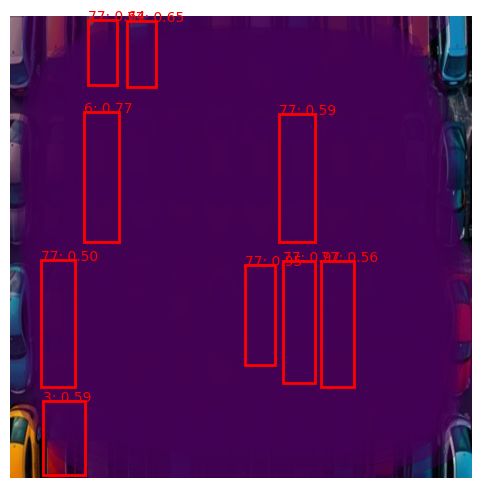

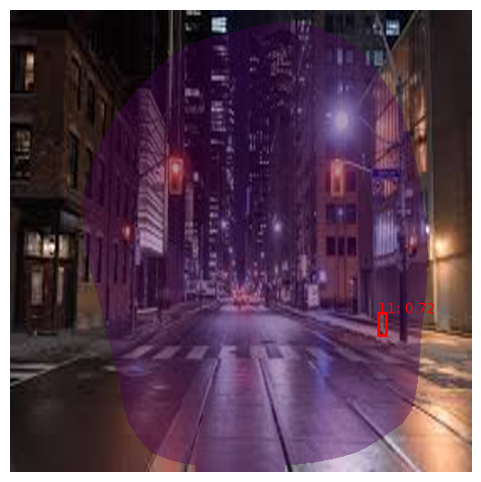

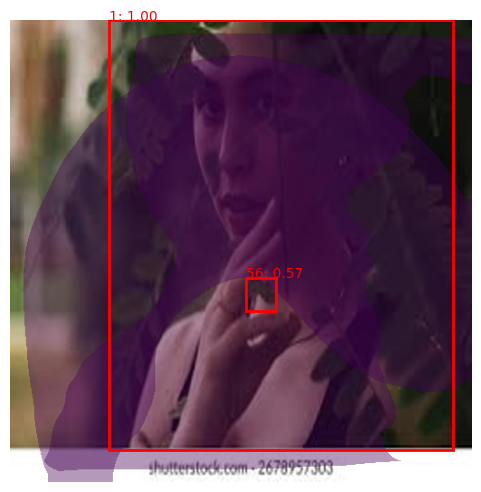

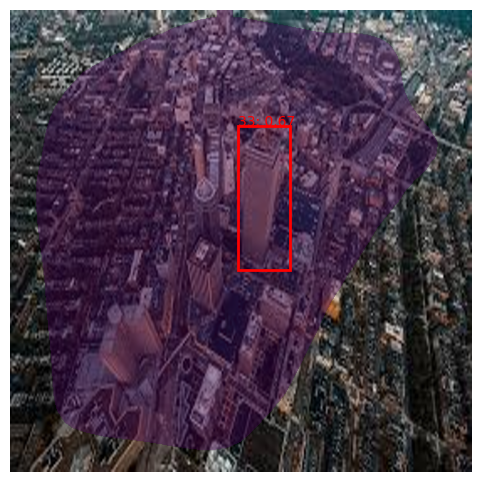

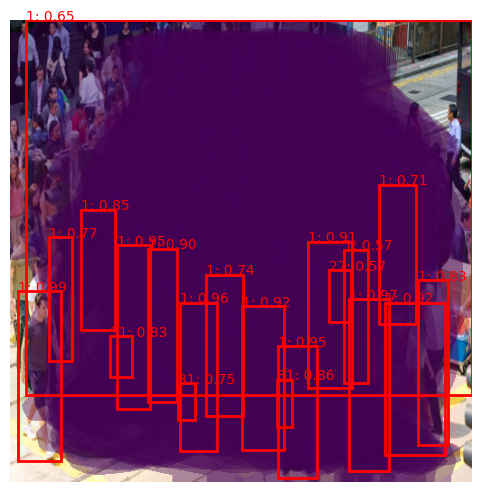

In [34]:
for img in images:
    outputs = run_inference(img)

    # Default threshold
    boxes, classes, scores, masks = extract_predictions(outputs, threshold=0.5)

    display_results(img, boxes, classes, scores, masks)

Running inference with threshold = 0.3


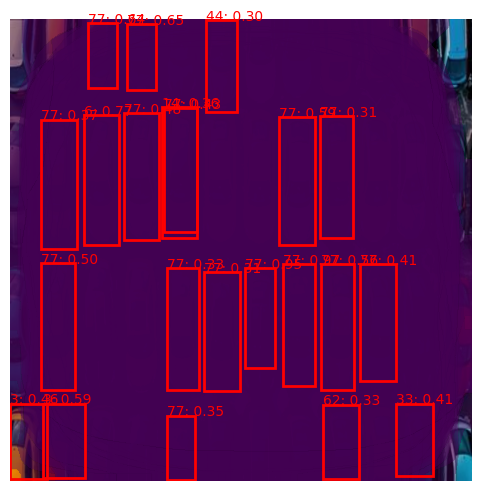

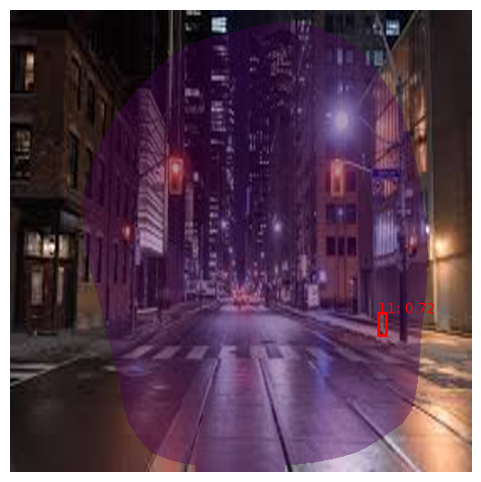

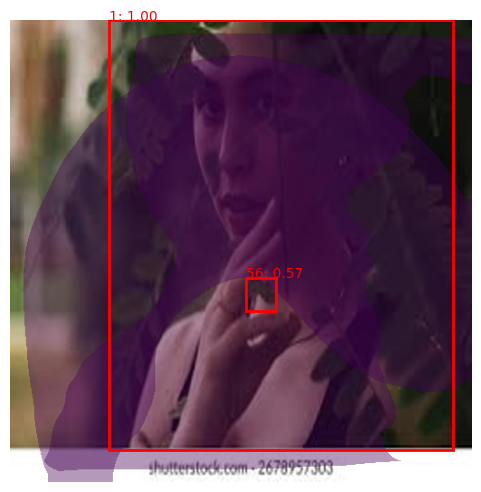

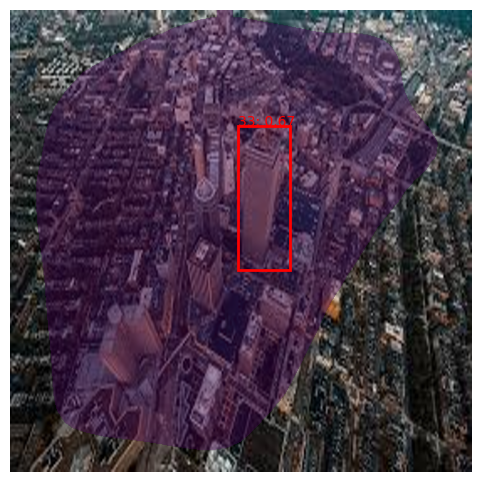

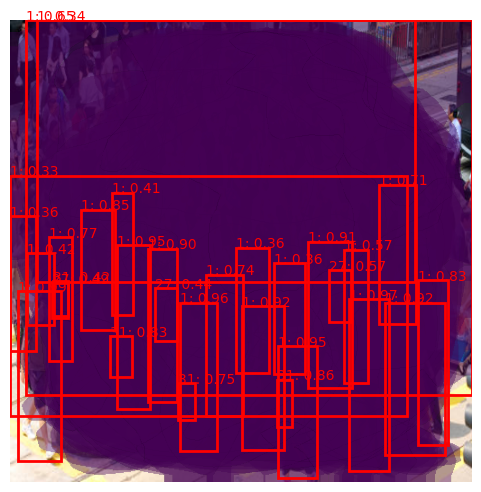

In [35]:
print("Running inference with threshold = 0.3")

for img in images:
    outputs = run_inference(img)

    boxes, classes, scores, masks = extract_predictions(outputs, threshold=0.3)

    display_results(img, boxes, classes, scores, masks)